In [2]:
import gymnasium as gym
import itertools
import math
import matplotlib
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import random
import ale_py
import tensorflow as tf
from tensorflow.keras import layers


import subprocess, sys

import numpy as np
import seaborn as sns

from tqdm import tqdm
import collections

# Make plots look nice
sns.set()
sns.set_context("notebook")
sns.set_style("whitegrid")

In [3]:
gym.register_envs(ale_py)

In [4]:
env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)


env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)

obs, info = env.reset()


print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"obs={obs}, reward={reward:.3f}, done={terminated}")

env.close()
print("✅ All good!")

Observation space: Box(0, 255, (4, 84, 84), uint8)
Action space: Discrete(9)
obs=[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]], reward=0.000, done=False
obs=[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 

In [5]:
inputs = tf.keras.Input(shape=(84, 84, 4))

x = layers.Conv2D(32, 8, strides=4, activation='relu')(inputs)
x = layers.Conv2D(64, 4, strides=2, activation='relu')(x)
x = layers.Conv2D(64, 3, strides=1, activation='relu')(x)

x = layers.Flatten()(x)
x = layers.Dense(512, activation='relu')(x)

outputs = layers.Dense(env.action_space.n)(x)

In [6]:
Q_net = tf.keras.Model(inputs, outputs)
T_net = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

@tf.function
def train_step(states, actions, targets):
    with tf.GradientTape() as tape:
        q_vals = Q_net(states)
        chosen_q = tf.gather(q_vals, actions, batch_dims=1)

        td_error = targets - chosen_q          
        td_error_clipped = tf.clip_by_value(td_error, -1, 1) 
        loss = tf.reduce_mean(tf.square(td_error_clipped))

    grads = tape.gradient(loss, Q_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, Q_net.trainable_variables))

In [7]:
@tf.function
def train_step(states, actions, targets):
    with tf.GradientTape() as tape:
        q_vals = Q_net(states)
        chosen_q = tf.gather(q_vals, actions, batch_dims=1)
        td_error = tf.clip_by_value(targets - chosen_q, -1, 1)
        loss = tf.reduce_mean(tf.square(td_error))
    grads = tape.gradient(loss, Q_net.trainable_variables)
    optimizer.apply_gradients(zip(grads, Q_net.trainable_variables))
    return loss

In [11]:
action_space = env.action_space
discount = 0.99

replay_buffer = collections.deque(maxlen=10000)

episode_rewards = []
step_count = 0
train_losses = []


print("Warming up replay buffer...")
while len(replay_buffer) < 5000:
    obs, info = env.reset()
    obs = np.transpose(np.array(obs), (1, 2, 0))[np.newaxis, ...]
    done = False
    while not done and len(replay_buffer) < 5000:
        action = env.action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward/50
        next_obs = np.transpose(np.array(next_obs), (1, 2, 0))[np.newaxis, ...]
        done = terminated or truncated
        replay_buffer.append([obs, action, reward, next_obs, terminated, truncated])
        obs = next_obs
print(f"Warmup done — buffer size: {len(replay_buffer)}")


for x in range(100):
    eps = max(0.05, 1.0 - step_count / 100000)

    obs, info = env.reset()
    obs = np.transpose(np.array(obs), (1, 2, 0))[np.newaxis, ...]
    done = False
    total_reward = 0

    if x % 20 == 0 and x > 0:
        recent_mean = np.mean(episode_rewards[-20:])
        recent_best = np.max(episode_rewards[-20:])
        print(f"Episode {x:4d} | eps={eps:.3f} | "
            f"mean={recent_mean:.1f} | best={recent_best:.1f} | "
            f"steps={step_count}")    


    while not done:

        step_count += 1
        if step_count % 1000 == 0:
            T_net.set_weights(Q_net.get_weights())

        if(random.random()>eps):
            action = int(tf.argmax(Q_net(obs, training=False)[0]))
        else:
            action = action_space.sample()


        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward/50

        next_obs = np.transpose(np.array(next_obs), (1, 2, 0))[np.newaxis, ...]

        done = terminated or truncated

        replay_buffer.append([obs, action, reward, next_obs, terminated, truncated])
        total_reward += reward

        obs = next_obs

        


        if len(replay_buffer)>1000:

            replays = random.sample(replay_buffer, 32)


            obss = np.vstack([r[0] for r in replays])
            actions = np.array([r[1] for r in replays])
            rewards = np.array([r[2] for r in replays], dtype=np.float32)
            next_obss = np.vstack([r[3] for r in replays])
            dones = np.array([r[4] or r[5] for r in replays], dtype=np.float32)
            


            next_q = tf.reduce_max(T_net(next_obss, training=False), axis=1)
            targets = rewards + discount * next_q * (1 - dones) 

            loss = train_step(obss, actions, targets)
            train_losses.append(float(loss))
            
            train_step(obss, actions, targets)

        if(terminated or truncated):
            episode_rewards.append(total_reward)
            print(f"Episode {x}, Reward: {total_reward}")


Q_net.save("dqn_asterix.keras")

Warming up replay buffer...
Warmup done — buffer size: 5000
Episode 0, Reward: 6.0
Episode 1, Reward: 6.0
Episode 2, Reward: 8.0
Episode 3, Reward: 3.0
Episode 4, Reward: 6.0
Episode 5, Reward: 5.0
Episode 6, Reward: 7.0
Episode 7, Reward: 15.0
Episode 8, Reward: 4.0
Episode 9, Reward: 4.0
Episode 10, Reward: 3.0
Episode 11, Reward: 8.0
Episode 12, Reward: 2.0
Episode 13, Reward: 2.0
Episode 14, Reward: 3.0
Episode 15, Reward: 4.0
Episode 16, Reward: 2.0
Episode 17, Reward: 4.0
Episode 18, Reward: 2.0
Episode 19, Reward: 5.0
Episode   20 | eps=0.949 | mean=5.0 | best=15.0 | steps=5063
Episode 20, Reward: 4.0
Episode 21, Reward: 13.0
Episode 22, Reward: 5.0
Episode 23, Reward: 8.0
Episode 24, Reward: 5.0
Episode 25, Reward: 11.0
Episode 26, Reward: 4.0
Episode 27, Reward: 8.0
Episode 28, Reward: 6.0
Episode 29, Reward: 4.0
Episode 30, Reward: 3.0
Episode 31, Reward: 3.0
Episode 32, Reward: 4.0
Episode 33, Reward: 4.0
Episode 34, Reward: 9.0
Episode 35, Reward: 16.0
Episode 36, Reward: 4

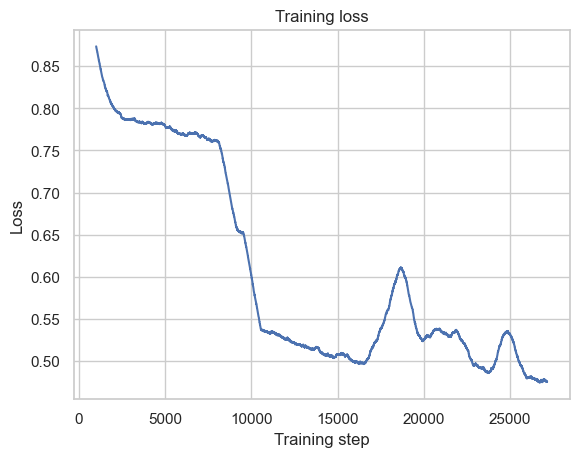

In [12]:
import pandas as pd

plt.plot(pd.Series(train_losses).rolling(1000).mean())
plt.xlabel('Training step')
plt.ylabel('Loss')
plt.title('Training loss')
plt.show()

In [17]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())
import subprocess
subprocess.run(['nvidia-smi'])

[]
False


CompletedProcess(args=['nvidia-smi'], returncode=0)

In [10]:
def evaluate(env, Q_net, n_episodes=50, render=False):
    rewards = []

    for ep in range(n_episodes):
        obs, info = env.reset()
        obs = np.transpose(np.array(obs), (1, 2, 0))[np.newaxis, ...]
        done = False
        total_reward = 0

        while not done:
            action = int(tf.argmax(Q_net(obs, training=False)[0]))
            obs, reward, terminated, truncated, info = env.step(action)
            obs = np.transpose(np.array(obs), (1, 2, 0))[np.newaxis, ...]
            done = terminated or truncated
            total_reward += reward

        rewards.append(total_reward)
        print(f"Episode {ep+1}: {total_reward:.0f}")

    print(f"\nMean: {np.mean(rewards):.1f}  |  "
          f"Std: {np.std(rewards):.1f}  |  "
          f"Best: {np.max(rewards):.1f}")
    return rewards

test_rewards = evaluate(env, Q_net, n_episodes=50)

Episode 1: 150
Episode 2: 150
Episode 3: 250
Episode 4: 150
Episode 5: 100
Episode 6: 100
Episode 7: 300
Episode 8: 150
Episode 9: 300
Episode 10: 50
Episode 11: 200
Episode 12: 150
Episode 13: 150
Episode 14: 100
Episode 15: 50
Episode 16: 400
Episode 17: 100
Episode 18: 400
Episode 19: 250
Episode 20: 150
Episode 21: 150
Episode 22: 300
Episode 23: 100
Episode 24: 150
Episode 25: 150
Episode 26: 200
Episode 27: 400
Episode 28: 100
Episode 29: 250
Episode 30: 350
Episode 31: 150
Episode 32: 100
Episode 33: 150
Episode 34: 200
Episode 35: 300
Episode 36: 400
Episode 37: 100
Episode 38: 250
Episode 39: 100
Episode 40: 100
Episode 41: 200
Episode 42: 150
Episode 43: 100
Episode 44: 150
Episode 45: 100
Episode 46: 150
Episode 47: 350
Episode 48: 300
Episode 49: 150
Episode 50: 100

Mean: 188.0  |  Std: 97.2  |  Best: 400.0


In [13]:
Q_net = tf.keras.models.load_model("dqn_asterix.keras")
render_env = gym.make("ALE/Asterix-v5", obs_type="grayscale", 
                       frameskip=1, render_mode="human")
render_env = gym.wrappers.AtariPreprocessing(render_env, frame_skip=4)
render_env = gym.wrappers.FrameStackObservation(render_env, 4)

evaluate(render_env, Q_net, n_episodes=3, render=True)
render_env.close()

: 

In [12]:
# See how the policy compares to pure random
random_rewards = []
for _ in range(50):
    obs, info = env.reset()
    done = False
    total = 0
    while not done:
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
        total += reward
        done = terminated or truncated
    random_rewards.append(total)

print(f"Random policy mean: {np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}")

Random policy mean: 267.0 ± 117.7


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import collections
import random
import gymnasium as gym

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Network ---
class DQN(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# --- Environment ---
env = gym.make("ALE/Asterix-v5", obs_type="grayscale", frameskip=1)
env = gym.wrappers.AtariPreprocessing(env, frame_skip=4)
env = gym.wrappers.FrameStackObservation(env, 4)

n_actions = env.action_space.n

# --- Models ---
Q_net = DQN(n_actions).to(device)
T_net = DQN(n_actions).to(device)
T_net.load_state_dict(Q_net.state_dict())
T_net.eval()

optimizer = optim.Adam(Q_net.parameters(), lr=1e-4)

# --- Helper ---
def process_obs(obs):
    # PyTorch is channels-first natively — no transpose needed
    obs = np.array(obs, dtype=np.float32) / 255.0   # (4, 84, 84)
    return torch.tensor(obs, device=device).unsqueeze(0)  # (1, 4, 84, 84)

# --- Train step ---
def train_step(obss, actions, targets):
    Q_net.train()
    q_vals = Q_net(obss)
    chosen_q = q_vals.gather(1, actions.unsqueeze(1)).squeeze(1)
    td_error = torch.clamp(targets - chosen_q, -1, 1)
    loss = (td_error ** 2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

# --- Replay buffer ---
replay_buffer = collections.deque(maxlen=100_000)
discount = 0.99
action_space = env.action_space
episode_rewards = []
train_losses = []
step_count = 0

# --- Warmup ---
print("Warming up replay buffer...")
while len(replay_buffer) < 5000:
    obs, info = env.reset()
    obs_t = process_obs(obs)
    done = False
    while not done and len(replay_buffer) < 5000:
        action = action_space.sample()
        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs_t = process_obs(next_obs)
        done = terminated or truncated
        # Store as CPU numpy to save GPU memory
        replay_buffer.append([
            obs_t.cpu().numpy(), action, reward,
            next_obs_t.cpu().numpy(), terminated, truncated
        ])
        obs_t = next_obs_t
print(f"Warmup done — buffer size: {len(replay_buffer)}")

# --- Training loop ---
for x in range(10_000):
    eps = max(0.05, 1.0 - step_count / 100_000)

    obs, info = env.reset()
    obs_t = process_obs(obs)
    done = False
    total_reward = 0
    total_reward_unscaled = 0

    if x % 20 == 0 and x > 0:
        recent_mean = np.mean(episode_rewards[-20:])
        recent_best = np.max(episode_rewards[-20:])
        print(f"Episode {x:4d} | eps={eps:.3f} | "
              f"mean={recent_mean:.1f} | best={recent_best:.1f} | "
              f"steps={step_count}")

    while not done:
        step_count += 1

        if step_count % 2000 == 0:
            T_net.load_state_dict(Q_net.state_dict())

        if random.random() > eps:
            with torch.no_grad():
                action = Q_net(obs_t).argmax(dim=1).item()
        else:
            action = action_space.sample()

        next_obs, reward, terminated, truncated, info = env.step(action)
        reward = reward / 50.0
        next_obs_t = process_obs(next_obs)
        done = terminated or truncated

        replay_buffer.append([
            obs_t.cpu().numpy(), action, reward,
            next_obs_t.cpu().numpy(), terminated, truncated
        ])
        total_reward += reward
        total_reward_unscaled += reward * 50
        obs_t = next_obs_t

        if len(replay_buffer) > 1000:
            replays = random.sample(replay_buffer, 32)

            obss      = torch.tensor(np.vstack([r[0] for r in replays]), device=device)
            actions   = torch.tensor([r[1] for r in replays], device=device, dtype=torch.long)
            rewards   = torch.tensor([r[2] for r in replays], device=device, dtype=torch.float32)
            next_obss = torch.tensor(np.vstack([r[3] for r in replays]), device=device)
            dones     = torch.tensor([r[4] or r[5] for r in replays], device=device, dtype=torch.float32)

            with torch.no_grad():
                next_q = T_net(next_obss).max(dim=1).values
            targets = rewards + discount * next_q * (1 - dones)

            loss = train_step(obss, actions, targets)
            train_losses.append(loss)

    episode_rewards.append(total_reward_unscaled)
    print(f"Episode {x}, Reward: {total_reward_unscaled:.0f}")

    if x % 500 == 0 and x > 0:
        torch.save(Q_net.state_dict(), f"dqn_checkpoint_ep{x}.pt")
        np.save(f"rewards_ep{x}.npy", np.array(episode_rewards))
        print(f"Checkpoint saved at episode {x}")

env.close()

Using device: cpu


ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: cannot import name 'NP_SUPPORTED_MODULES' from 'torch._dynamo.utils' (c:\Users\acrab\anaconda3\envs\RL\lib\site-packages\torch\_dynamo\utils.py)